Nome: Maria Eduarda Rezende Rodrigues
RA: 165873

In [61]:
# imports
import math
import matplotlib.pyplot as plt
import pandas as pd

In [62]:
# inicialização das variáveis utilizadas no código
# Variáveis parte 3
x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
n = list(range(5))

pi = math.pi

data = {
    "Aproximação por truncamento": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Aproximação por arredondamento": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Erro absoluto": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Erro relativo": {3.14159265: [], 98.76543: [], 0.00498765: []},
    "Erro percentual": {3.14159265: [], 98.76543: [], 0.00498765: []}
}

df = pd.DataFrame(data)

plt.style.use("seaborn-v0_8-whitegrid")

# Variáveis parte 4
pressao_sist = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

In [63]:
# função para calcular erro absoluto, relativo ou percentual
def calc_erro(valor_referencia, valor_aproximado, tipo_erro):
    if tipo_erro == 'abs':
        erro = abs(valor_referencia - valor_aproximado)
    elif tipo_erro == 'rel':
        erro = abs((valor_referencia - valor_aproximado) / valor_referencia)
    elif tipo_erro == 'percent':
        erro = abs((valor_referencia - valor_aproximado) / valor_referencia) * 100
    else:
        print("Erro inválido. Opções -> abs, rel, percent")
    
    return erro

# função para truncar sem arredondar
def trunc(x, n):
    return math.trunc((10 ** n) * x) / (10 ** n)

Aproximação por truncamento (x1): 3.0, 3.1, 3.14, 3.141, 3.1415
Aproximação por truncamento (x2): 98.0, 98.7, 98.76, 98.765, 98.7654
Aproximação por truncamento (x3): 0.0, 0.0, 0.0, 0.004, 0.0049
Aproximação por arredondamento (x1): 3.0, 3.1, 3.14, 3.142, 3.1416
Aproximação por arredondamento (x2): 99.0, 98.8, 98.77, 98.765, 98.7654
Aproximação por arredondamento (x3): 0.0, 0.0, 0.0, 0.005, 0.005
Erro para x1 (truncamento):
  abs      = [0.1415926500000002, 0.04159265000000012, 0.0015926500000000843, 0.0005926500000001944, 9.265000000002743e-05]
  rel      = [0.04507034035746175, 0.013239351702710444, 0.000506956240809923, 0.0001886463542624453, 2.949141098863579e-05]
  percent  = [4.507034035746175, 1.3239351702710445, 0.050695624080992305, 0.01886463542624453, 0.002949141098863579]
Erro para x1 (arredondamento):
  abs      = [0.1415926500000002, 0.04159265000000012, 0.0015926500000000843, 0.00040734999999969546, 7.349999999739509e-06]
  rel      = [0.04507034035746175, 0.013239351702

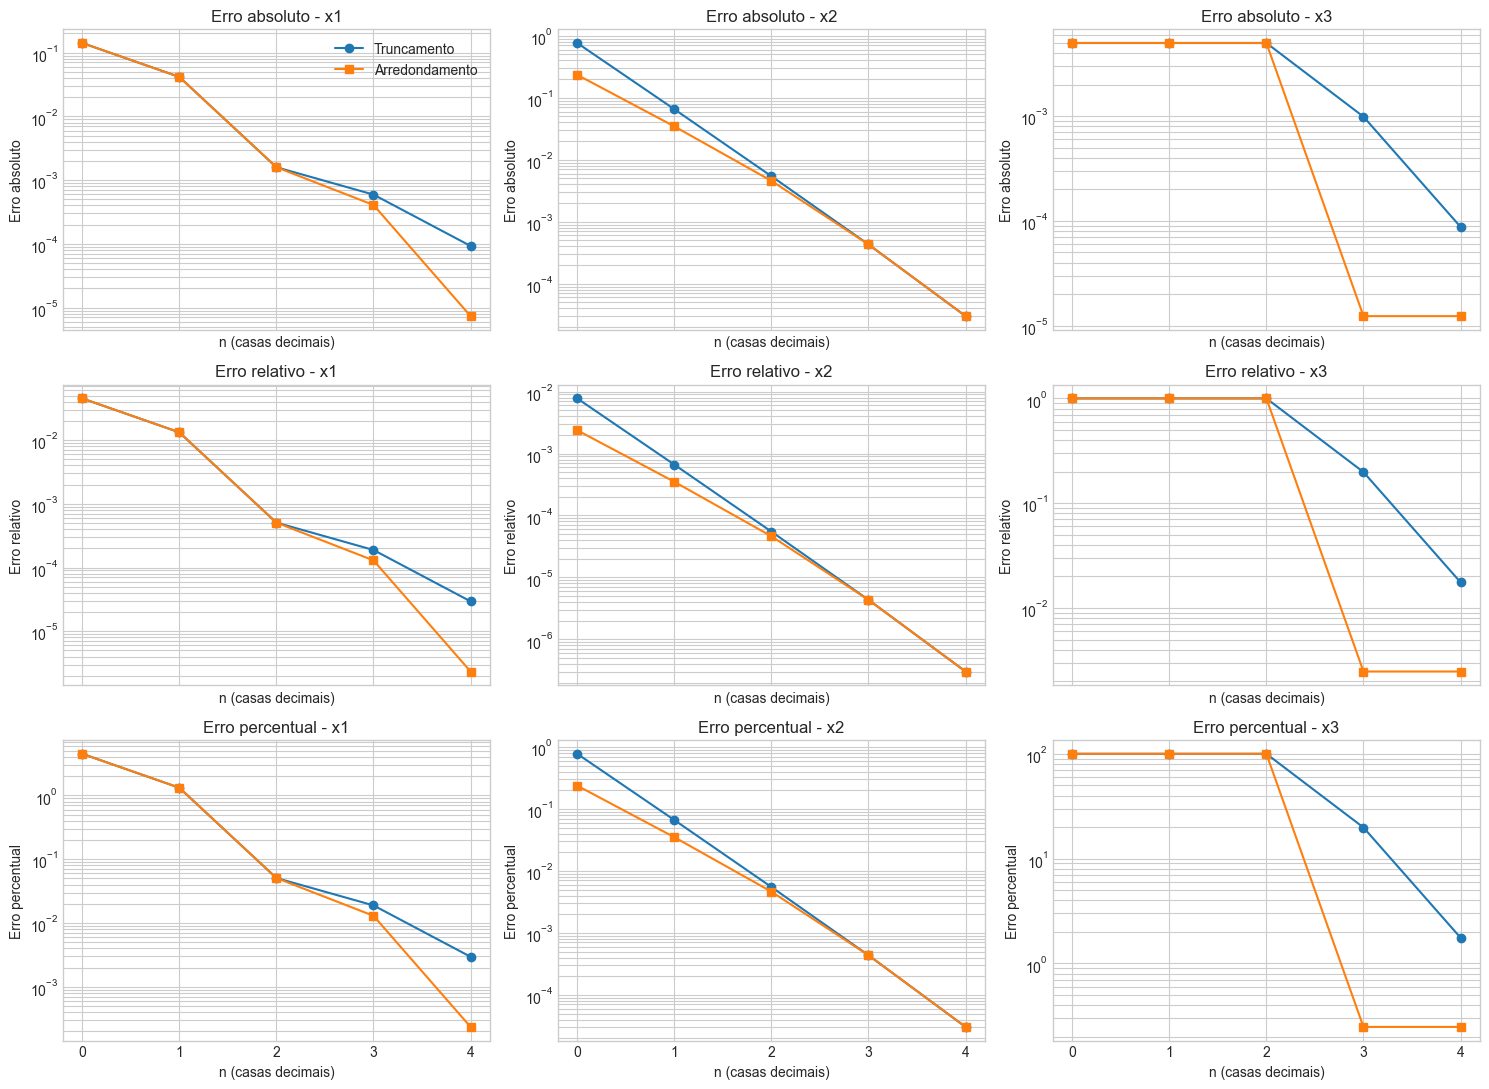

In [64]:
# 3.1
for nome, valor in [("x1", x1), ("x2", x2), ("x3", x3)]:
    aproximacoes = [trunc(valor, casa_decimal) for casa_decimal in n]
    print(
        f"Aproximação por truncamento ({nome}): "
        + ", ".join(map(str, aproximacoes))
    )
    df.at[valor, "Aproximação por truncamento"] = aproximacoes


for nome, valor in [("x1", x1), ("x2", x2), ("x3", x3)]:
    aproximacoes = [round(valor, casa_decimal) for casa_decimal in n]
    print(
        f"Aproximação por arredondamento ({nome}): "
        + ", ".join(map(str, aproximacoes))
    )
    df.at[valor, "Aproximação por arredondamento"] = aproximacoes

# 3.2
for nome, valor_referencia in [("x1", x1), ("x2", x2), ("x3", x3)]:
    trunc_abs = [
        calc_erro(valor_referencia, trunc(valor_referencia, casa), "abs")
        for casa in n
    ]
    trunc_rel = [
        calc_erro(valor_referencia, trunc(valor_referencia, casa), "rel")
        for casa in n
    ]
    trunc_percent = [
        calc_erro(valor_referencia, trunc(valor_referencia, casa), "percent")
        for casa in n
    ]

    arred_abs = [
        calc_erro(valor_referencia, round(valor_referencia, casa), "abs")
        for casa in n
    ]
    arred_rel = [
        calc_erro(valor_referencia, round(valor_referencia, casa), "rel")
        for casa in n
    ]
    arred_percent = [
        calc_erro(valor_referencia, round(valor_referencia, casa), "percent")
        for casa in n
    ]

    print(f"Erro para {nome} (truncamento):")
    print(f"  abs      = {trunc_abs}")
    print(f"  rel      = {trunc_rel}")
    print(f"  percent  = {trunc_percent}")

    print(f"Erro para {nome} (arredondamento):")
    print(f"  abs      = {arred_abs}")
    print(f"  rel      = {arred_rel}")
    print(f"  percent  = {arred_percent}")

    df.at[valor_referencia, "Erro absoluto"] = {
        "truncamento": trunc_abs,
        "arredondamento": arred_abs,
    }
    df.at[valor_referencia, "Erro relativo"] = {
        "truncamento": trunc_rel,
        "arredondamento": arred_rel,
    }
    df.at[valor_referencia, "Erro percentual"] = {
        "truncamento": trunc_percent,
        "arredondamento": arred_percent,
    }

# 3.3
print(df)

# 3.4 e 3.5
valores = [x1, x2, x3]
nomes = ["x1", "x2", "x3"]
tipos_erro = [
    ("abs", "Erro absoluto"),
    ("rel", "Erro relativo"),
    ("percent", "Erro percentual"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)

for linha, (tipo, titulo) in enumerate(tipos_erro):
    for coluna, (nome, valor) in enumerate(zip(nomes, valores)):
        erro_trunc = [
            calc_erro(valor, trunc(valor, casas), tipo)
            for casas in n
        ]
        erro_arred = [
            calc_erro(valor, round(valor, casas), tipo)
            for casas in n
        ]

        ax = axes[linha, coluna]
        ax.semilogy(n, erro_trunc, marker="o", label="Truncamento")
        ax.semilogy(n, erro_arred, marker="s", label="Arredondamento")

        ax.set_title(f"{titulo} - {nome}")
        ax.set_xticks(n)
        ax.set_xlabel("n (casas decimais)")
        ax.set_ylabel(titulo)
        ax.grid(True, which="both")

        if linha == 0 and coluna == 0:
            ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 4.1.1
pressao_sist_arrednd = []
pressao_sist_trunc = []

print(f"Dados originais: {pressao_sist}")

# 4.1.2
for x in pressao_sist:
    y = round(x)
    pressao_sist_arrednd.append(y)
print(f"Dados arredondados: {pressao_sist_arrednd}")

# 4.1.3
for x in pressao_sist:
    y = trunc(x, 1)
    pressao_sist_trunc.append(y)
print(f"Dados truncados: {pressao_sist_trunc}")



Dados originais: [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
Dados arredondados: [122, 120, 122, 120, 121, 121, 122, 121, 120, 122]
Dados truncados: [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
